# Autoencoder Fashion-MNIST — Training Multi Latent Dimension
Notebook ini melatih Autoencoder dengan tiga ukuran latent dimension: **2, 8, 32**.
Untuk setiap latent dimension, model (encoder + decoder + full autoencoder) disimpan ke `.pth`,
loss curve diplot, dan beberapa contoh rekonstruksi ditampilkan & disimpan sebagai gambar.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 1. Dataset

In [4]:
class FashionMNISTDataset(Dataset):
    """Membaca file CSV Fashion-MNIST (kolom pertama = label, sisanya 784 pixel)."""
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((32, 32)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx].values
        label = int(row[0])
        image = row[1:].astype(np.uint8).reshape(28, 28)
        image = np.expand_dims(image, axis=2)
        image = self.transform(image)
        return image, image, label


# Sesuaikan path ini dengan dataset yang kamu attach di Kaggle
TRAIN_CSV = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
TEST_CSV = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv"

train_dataset = FashionMNISTDataset(TRAIN_CSV)
test_dataset = FashionMNISTDataset(TEST_CSV)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Jumlah data train:", len(train_dataset))
print("Jumlah data test :", len(test_dataset))


Jumlah data train: 60000
Jumlah data test : 10000


## 2. Arsitektur Model (latent_dim bisa diatur)

In [5]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 128x4x4
            nn.ReLU(),
            nn.Flatten(),                                          # 2048
            nn.Linear(128 * 4 * 4, latent_dim)                      # bottleneck
        )

    def forward(self, x):
        return self.encoder(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


## 3. Fungsi Training

In [6]:
def train_autoencoder(latent_dim, epochs=10, lr=1e-3, save_dir="/kaggle/working"):
    model = Autoencoder(latent_dim=latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(epochs):
        total_loss = 0
        for imgs, _, _ in tqdm(train_loader, desc=f"[latent={latent_dim}] Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history.append(avg_loss)
        print(f"[latent={latent_dim}] Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    # Simpan model: full autoencoder + encoder + decoder terpisah
    torch.save(model.state_dict(), os.path.join(save_dir, f"autoencoder_fashion_mnist_dim{latent_dim}.pth"))
    torch.save(model.encoder.state_dict(), os.path.join(save_dir, f"encoder_fashion_mnist_dim{latent_dim}.pth"))
    torch.save(model.decoder.state_dict(), os.path.join(save_dir, f"decoder_fashion_mnist_dim{latent_dim}.pth"))

    return model, history


## 4. Training untuk Latent Dimension 2, 8, 32

In [7]:
latent_dims = [2, 8, 32]
EPOCHS = 10  # silakan naikkan jika ingin loss lebih turun

models = {}
histories = {}

for dim in latent_dims:
    model, history = train_autoencoder(dim, epochs=EPOCHS)
    models[dim] = model
    histories[dim] = history


[latent=2] Epoch 1/10: 100%|██████████| 469/469 [00:21<00:00, 21.45it/s]


[latent=2] Epoch [1/10] Loss: 0.036586


[latent=2] Epoch 2/10: 100%|██████████| 469/469 [00:21<00:00, 22.28it/s]


[latent=2] Epoch [2/10] Loss: 0.025088


[latent=2] Epoch 3/10: 100%|██████████| 469/469 [00:20<00:00, 22.56it/s]


...

[latent=32] Epoch [8/10] Loss: 0.004128


[latent=32] Epoch 9/10: 100%|██████████| 469/469 [00:20<00:00, 22.59it/s]


[latent=32] Epoch [9/10] Loss: 0.004011


[latent=32] Epoch 10/10: 100%|██████████| 469/469 [00:20<00:00, 22.53it/s]

[latent=32] Epoch [10/10] Loss: 0.003907


## 5. Plot Training Loss untuk Setiap Latent Dimension

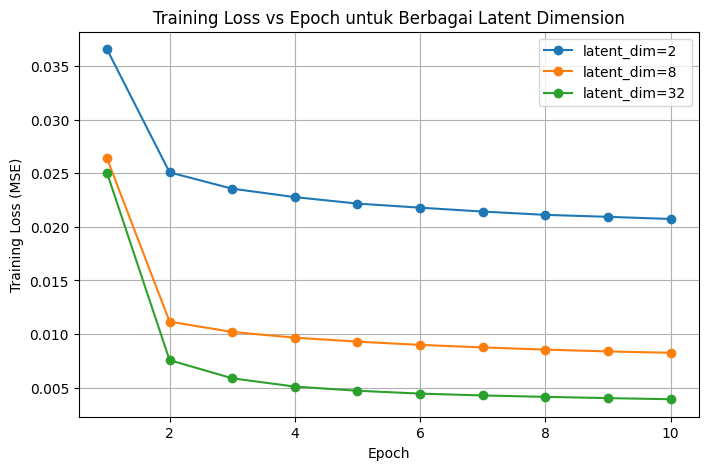


Loss akhir per latent dimension:
  latent_dim=2: 0.020737
  latent_dim=8: 0.008243
  latent_dim=32: 0.003907


In [8]:
plt.figure(figsize=(8, 5))
for dim in latent_dims:
    plt.plot(range(1, EPOCHS + 1), histories[dim], marker="o", label=f"latent_dim={dim}")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss vs Epoch untuk Berbagai Latent Dimension")
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLoss akhir per latent dimension:")
for dim in latent_dims:
    print(f"  latent_dim={dim}: {histories[dim][-1]:.6f}")


## 6. Contoh Gambar Asli vs Rekonstruksi (untuk setiap latent dimension)

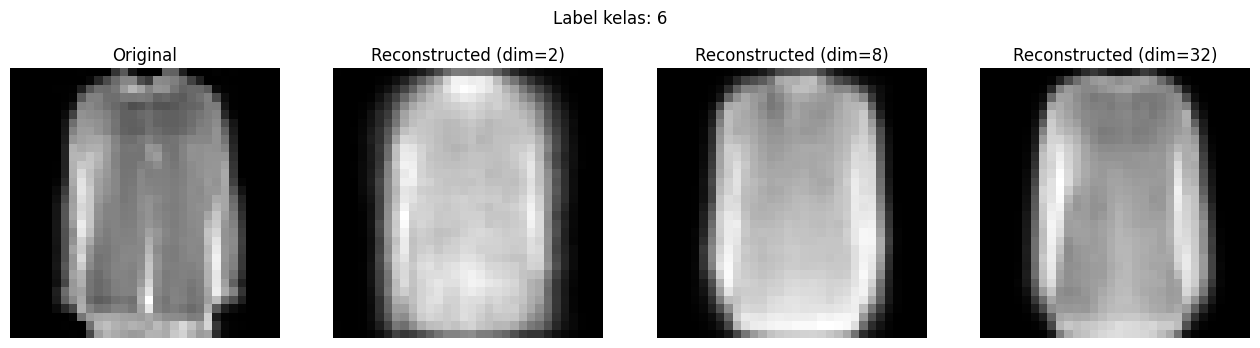

In [9]:
sample_idx = 7  # ubah sesuai keinginan

# Ambil satu gambar test
img, _, label = test_dataset[sample_idx]
img_batch = img.unsqueeze(0).to(device)

fig, axes = plt.subplots(1, len(latent_dims) + 1, figsize=(4 * (len(latent_dims) + 1), 4))

axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i, dim in enumerate(latent_dims):
    model = models[dim]
    model.eval()
    with torch.no_grad():
        recon = model(img_batch).squeeze().cpu().numpy()
    axes[i + 1].imshow(recon, cmap="gray")
    axes[i + 1].set_title(f"Reconstructed (dim={dim})")
    axes[i + 1].axis("off")

plt.suptitle(f"Label kelas: {label}")
plt.savefig("/kaggle/working/reconstruction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Tabel Perbandingan (untuk laporan)
Sel di bawah menghasilkan tabel ringkas loss akhir per latent dimension yang bisa kamu salin ke laporan.


In [10]:
comparison_df = pd.DataFrame({
    "Latent Dimension": latent_dims,
    "Loss Akhir": [histories[d][-1] for d in latent_dims],
})
comparison_df


,Latent Dimension,Loss Akhir
0,2,0.020737
1,8,0.008243
2,32,0.003907
